# Theory

High-boost filtering is an image enhancement technique that sharpens an image by emphasizing its high-frequency components (edges and fine details). The process involves subtracting a blurred (low-pass filtered) version of the image from the original image to obtain a high-pass image, and then adding a scaled version of this high-pass image back to the original. The mathematical expression for high-boost filtering is:

$$
\text{High-boost Image} = A \cdot f(x, y) - \text{Low-pass}(f(x, y))
$$

where $f(x, y)$ is the original image, $A$ is the amplification factor ($A > 1$), and $\text{Low-pass}(f(x, y))$ is the smoothed version of the image. When $A = 1$, the result is simply the high-pass filtered image; for $A > 1$, the original image is boosted, enhancing details and edges.



In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
def sharp_filter(input_image):
  img = input_image.resize((400,400), Image.Resampling.LANCZOS)

  


  # convert to numpy array 
  numpy_image = np.array(img)
  # array for padding
  array_b = np.zeros((402,402))

  # to pad initial array with zeros in all side
  array_b[1:401,1:401] = numpy_image

  #defining filter
  filter_array = np.array([[-1/9,-1/9,-1/9],
                         [-1/9,8/9,-1/9],
                         [-1/9,-1/9,-1/9]])
  
  #creating empty list
  lst = []

  for i in range(400):
    for j in range(400):
      #extracting part of array equal to filter size
      array_c = array_b[i:(3+i),j:(3+j)]
    
     #applying filter
      array_mul = np.multiply(filter_array,array_c)
      array_sum = np.sum(array_mul)
    
      # putting calculated value in list
      lst.append(array_sum)

  # resizing lst to shape of original array
  final_array = np.resize(lst,(400,400))

  final_image = Image.fromarray(final_array)
  final_image= final_image.convert("L")

    
  return final_image
  

In [3]:
def high_boost(input_image):
  high_pass = sharp_filter(input_image)
  img = input_image.resize((400,400), Image.Resampling.LANCZOS)
  # convert to numpy array 
  numpy_image = np.array(img)

  A = 3
  high_boost = (A-1)*numpy_image + high_pass
  final_image = Image.fromarray(high_boost)
  final_image= final_image.convert("L")

  fig = plt.figure()
  fig.set_figheight(10)
  fig.set_figwidth(10)

  #plotting original image
  fig.add_subplot(1,2,1)
  plt.imshow(img, cmap='gray')
  plt.title('Original')

  #plotting filtered image
  fig.add_subplot(1,2,2)
  plt.imshow(final_image, cmap='gray')
  plt.title('High-boost image')



  return final_image



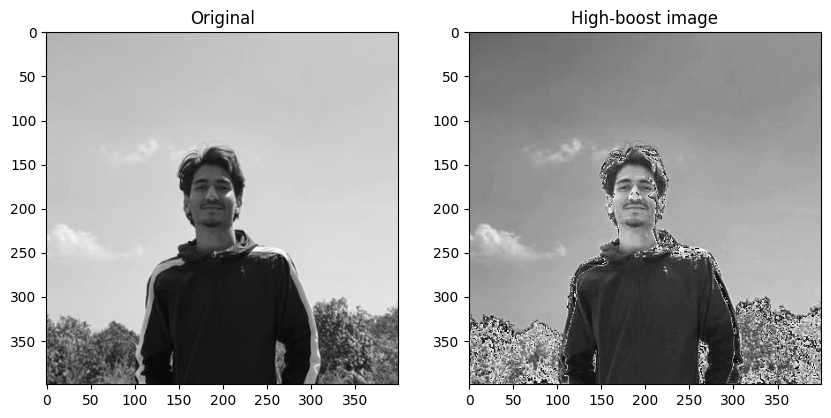

: 

In [ ]:
# reading image and converting to gray scale
img = Image.open('img/prakash.jpg').convert('L')
# Calling smooth function 
a = high_boost(img)

# Conclusion

The high-boost filtering technique effectively sharpens images by amplifying high-frequency details while retaining the overall structure. By adjusting the amplification factor $A$, the degree of enhancement can be controlled. This method is particularly useful for highlighting edges and fine structures in images, making it valuable in applications such as medical imaging, document analysis, and photography enhancement. The implementation demonstrates that high-boost filtering can significantly improve image clarity and detail.